# Bank Marketing Dataset

**Pergunta:** Quais fatores estão mais associados à adesão ao depósito a prazo, e como o banco pode priorizar contatos para aumentar a taxa de conversão das campanhas?

Camille Porto de Sousa

### 0. Carregamento

In [ ]:
import pandas as pd
import numpy as np

# O CSV original usa ';' como separador (o padrão do pandas é ',')
URL = "https://raw.githubusercontent.com/akhil12028/Bank-Marketing-data-set-analysis/master/bank-additional-full.csv"
df = pd.read_csv(URL, sep=";")

# Guardamos uma cópia do bruto para comparar antes/depois da limpeza
df_bruto = df.copy()
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## 1. Descrição inicial do dataset
Informações: tamanho, tipos e separação entre variáveis numéricas e categóricas.

In [ ]:
print("Linhas x Colunas:", df.shape)
print("Memória:", round(df.memory_usage(deep=True).sum()/1024**2, 2), "MB")

num = df.select_dtypes(include=np.number).columns
cat = df.select_dtypes(exclude=np.number).columns
print(f"\nNuméricas ({len(num)}): {list(num)}")
print(f"\nCategóricas ({len(cat)}): {list(cat)}")

Linhas x Colunas: (41188, 21)
Memória: 26.8 MB

Numéricas (10): ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Categóricas (11): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']


In [ ]:
# Visão geral: tipos e contagem de não-nulos por coluna
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

**Leitura:** o dataset tem **41.188 registros e 21 colunas** (10 numéricas, 11 categóricas), ocupando 27 MB. A coluna `y` é o alvo (aderiu ou não ao depósito).

## 2. Análise de valores ausentes
Procuramos dados faltando — primeiro os ausentes "clássicos" (`NaN`).

In [ ]:
# Contagem de NaN por coluna
ausentes = df.isnull().sum()
print("Total de NaN no dataset:", ausentes.sum())
print(ausentes[ausentes > 0] if ausentes.sum() else "Nenhuma coluna com NaN.")

Total de NaN no dataset: 0
Nenhuma coluna com NaN.


In [ ]:
# ATENÇÃO: não há NaN, mas a ausência aparece MASCARADA como o texto 'unknown'.
# Por isso medimos 'unknown' em cada coluna categórica:
for c in cat:
    n = (df[c] == 'unknown').sum()
    if n > 0:
        print(f"{c:11s}: {n:5d} 'unknown' ({100*n/len(df):.2f}%)")

job        :   330 'unknown' (0.80%)
marital    :    80 'unknown' (0.19%)
education  :  1731 'unknown' (4.20%)
default    :  8597 'unknown' (20.87%)
housing    :   990 'unknown' (2.40%)
loan       :   990 'unknown' (2.40%)


**Leitura:** **zero `NaN`**, mas existe **ausência mascarada**: a categoria literal `'unknown'`
funciona como dado faltante. É forte em `default` (**20,9%**) e `education` (4,2%).
Decisão de tratamento na seção 8.

## 3. Análise de duplicatas
Registros idênticos não acrescentam informação e podem enviesar contagens.

In [ ]:
# Quantas linhas são completamente idênticas a outra?
print("Linhas duplicadas:", df.duplicated().sum())

# Mostramos um exemplo de par duplicado para evidência
exemplo = df[df.duplicated(keep=False)].sort_values(list(df.columns)).head(2)
exemplo

Linhas duplicadas: 12


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
28476,24,services,single,high.school,no,yes,no,cellular,apr,tue,...,1,999,0,nonexistent,-1.8,93.075,-47.1,1.423,5099.1,no
28477,24,services,single,high.school,no,yes,no,cellular,apr,tue,...,1,999,0,nonexistent,-1.8,93.075,-47.1,1.423,5099.1,no


**Leitura:** há 12 linhas duplicadas. Como não há um identificador único de cliente, linhas 100% iguais são, com muita probabilidade, repetições — serão removidas (seção 8).

## 4. Verificação dos tipos de dados
Conferimos se cada coluna está com um tipo coerente com seu significado.

In [ ]:
# Tabela: coluna, tipo atual, avaliação
aval = []
for c in df.columns:
    t = str(df[c].dtype)
    ok = "OK"
    if c in cat: ok = "OK (categórica como texto)"
    if c in ['age','duration','campaign','pdays','previous']: ok = "OK (inteiro)"
    if c in num and df[c].dtype == float: ok = "OK (decimal)"
    aval.append([c, t, ok])
pd.DataFrame(aval, columns=['coluna','tipo_atual','avaliação'])

,coluna,tipo_atual,avaliação
0,age,int64,OK (inteiro)
1,job,object,OK (categórica como texto)
2,marital,object,OK (categórica como texto)
3,education,object,OK (categórica como texto)
4,default,object,OK (categórica como texto)
5,housing,object,OK (categórica como texto)
6,loan,object,OK (categórica como texto)
7,contact,object,OK (categórica como texto)
8,month,object,OK (categórica como texto)
9,day_of_week,object,OK (categórica como texto)


**Leitura:** os tipos estão **adequados** — inteiros para contagens/idade, decimais para os
indicadores macroeconômicos e texto para as categóricas. A única ressalva é `pdays`: é inteiro,
mas usa o código **999** como "nunca contatado" (tratado na seção 5). Opcionalmente, converter as
categóricas para o tipo `category` reduziria memória, mas não é obrigatório.

## 5. Valores inválidos ou incoerentes
Procuramos valores que não fazem sentido no contexto de negócio.

In [ ]:
# 5.1 - pdays = 999 é um CÓDIGO ('nunca contatado'), não um número real de dias
print("pdays == 999:", (df['pdays']==999).sum(), f"({100*(df['pdays']==999).mean():.1f}%)")

# 5.2 - Ligações de 0 segundo: contato que efetivamente não aconteceu
zero = df[df['duration']==0]
print("duration == 0:", len(zero), "| desfecho:", zero['y'].value_counts().to_dict())

# 5.3 - 'default' = yes (cliente assumidamente inadimplente): quase inexistente
print("default == 'yes':", (df['default']=='yes').sum(), "registros")

# 5.4 - Faixas plausíveis e ausência de negativos onde não pode haver
print("age min/max:", df['age'].min(), "-", df['age'].max())
for c in ['age','duration','campaign','previous']:
    print(f"  {c}: {(df[c]<0).sum()} valores negativos")

pdays == 999: 39673 (96.3%)
duration == 0: 4 | desfecho: {'no': 4}
default == 'yes': 3 registros
age min/max: 17 - 98
  age: 0 valores negativos
  duration: 0 valores negativos
  campaign: 0 valores negativos
  previous: 0 valores negativos


**Leitura:**
- `pdays = 999` em **96,3%** das linhas é um **valor-sentinela** (não um número de dias). Vira a flag
`contatado_antes` e o 999 é substituído por `NaN`.
- **4 ligações de 0 segundo**, todas com desfecho `no` — coerente (ligação que não aconteceu não converte);
podem ser marcadas/descartadas.
- `default = 'yes'` só em **3 registros**: incomum, mas plausível (ninguém costuma admitir inadimplência).
- **Nenhum valor negativo** e idade entre 17 e 98 — dentro do esperado.

## 6. Padronização de categorias
Verificamos se há categorias escritas de formas diferentes para o mesmo significado
(espaços extras, maiúsculas/minúsculas misturadas, sinônimos).

In [ ]:
# Para cada categórica: detecta espaços nas pontas e duplicação por caixa (case)
problemas = 0
for c in cat:
    u = df[c].dropna().unique()
    espacos = [v for v in u if v != v.strip()] # ' valor '
    low = pd.Series([v.lower() for v in u])
    por_caso = low[low.duplicated()].tolist() # 'Sim' vs 'sim'
    if espacos or por_caso:
        problemas += 1
        print(f"{c}: espaços={espacos} | caso={por_caso}")
print("Colunas com inconsistência de escrita:", problemas)

# Conferência manual das categorias de duas colunas-chave
print("\njob      :", sorted(df['job'].unique()))
print("education:", sorted(df['education'].unique()))

Colunas com inconsistência de escrita: 0

job      : ['admin.', 'blue-collar', 'entrepreneur', 'housemaid', 'management', 'retired', 'self-employed', 'services', 'student', 'technician', 'unemployed', 'unknown']
education: ['basic.4y', 'basic.6y', 'basic.9y', 'high.school', 'illiterate', 'professional.course', 'university.degree', 'unknown']


**Leitura:** **nenhuma inconsistência de escrita** — não há espaços extras nem mistura de
maiúsculas/minúsculas; cada categoria aparece de uma única forma. O `'unknown'` **não é** erro de
padronização, e sim ausência mascarada (já tratada na seção 2). Conclusão: as categorias já estão
padronizadas.

## 7. Identificação de outliers
Usamos o método do **IQR** (intervalo interquartil) nas colunas numéricas de contagem/duração.
Um valor é outlier se estiver abaixo de Q1−1,5·IQR ou acima de Q3+1,5·IQR.

,coluna,limites_IQR,nº_outliers,%,máx
0,age,"[9.5, 69.5]",469,1.1%,98
1,duration,"[-223.5, 644.5]",2963,7.2%,4918
2,campaign,"[-2.0, 6.0]",2406,5.8%,56
3,previous,"[0.0, 0.0]",5625,13.7%,7


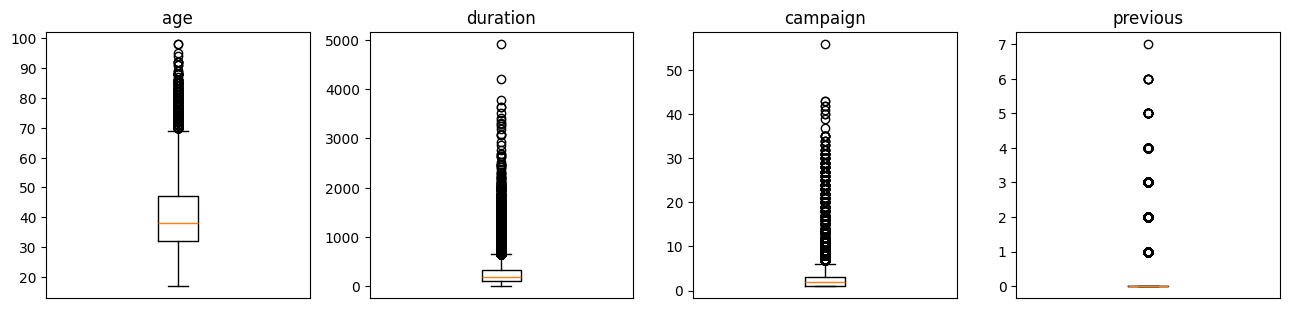

In [ ]:
import matplotlib.pyplot as plt
resumo = []
for c in ['age','duration','campaign','previous']:
    q1, q3 = df[c].quantile([.25, .75]); iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    n = ((df[c] < lo) | (df[c] > hi)).sum()
    resumo.append([c, f"[{lo:.1f}, {hi:.1f}]", n, f"{100*n/len(df):.1f}%", df[c].max()])
display(pd.DataFrame(resumo, columns=['coluna','limites_IQR','nº_outliers','%','máx']))

# Boxplots para visualizar
fig, ax = plt.subplots(1, 4, figsize=(13,3.2))
for a,c in zip(ax, ['age','duration','campaign','previous']):
    a.boxplot(df[c], showfliers=True); a.set_title(c); a.set_xticks([])
plt.tight_layout(); plt.show()

**Leitura — e por que NÃO removemos cegamente:**
- `duration` (7,2%) e `campaign` (5,8%): caudas longas **reais** — existem ligações muito longas e
clientes reabordados muitas vezes (até 56 contatos). São comportamentos de negócio, não erros.
- `previous` (13,7%): os "outliers" são justamente os clientes contatados em campanhas anteriores —
uma das informações **mais valiosas** da análise.
- `age` (1,1%): idosos acima de 69 anos, perfeitamente plausíveis.

**Decisão:** manter os outliers (são legítimos). Se a etapa de modelagem exigir, pode-se *capar*
(winsorizar) `campaign`, mas sem descartar registros.

## 8. Tratamentos realizados (consolidação)
Resumo das ações de limpeza decididas a partir dos diagnósticos acima.

In [ ]:
# (a) Remover duplicatas exatas
antes = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Duplicatas removidas: {antes - len(df)} | linhas restantes: {len(df)}")

# (b) Alvo numérico para análises posteriores do grupo
df['y_bin'] = (df['y'] == 'yes').astype(int)

# (c) Tratar o sentinela 999 de pdays
df['contatado_antes'] = (df['pdays'] != 999).astype(int)  # flag nova
df['pdays'] = df['pdays'].replace(999, np.nan)            # 999 vira ausente real

# (d) 'unknown' MANTIDO como categoria (apagar enviesaria a base; ver seção 2)

# (e) Marcar ligações de 0s (contato que não ocorreu)
df['ligacao_valida'] = (df['duration'] > 0).astype(int)

print("\nResumo final da limpeza:")
print(" - shape:", df.shape)
print(" - NaN agora (apenas pdays tratado):", df.isnull().sum().sum())
print(" - novas colunas: y_bin, contatado_antes, ligacao_valida")

# BASE LIMPA
df.to_csv("bank_limpo.csv", index=False)
print("\nArquivo salvo:", df.shape[0], "linhas x", df.shape[1], "colunas")

from google.colab import files
files.download("bank_limpo.csv")

Duplicatas removidas: 12 | linhas restantes: 41176

Resumo final da limpeza:
 - shape: (41176, 24)
 - NaN agora (apenas pdays tratado): 39661
 - novas colunas: y_bin, contatado_antes, ligacao_valida

Arquivo salvo: 41176 linhas x 24 colunas


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Entregáveis
| Item | Diagnóstico | Tratamento |
|---|---|---|
| Valores ausentes | 0 NaN, mas `'unknown'` mascarado (default 20,9%) | Mantido como categoria própria |
| Duplicatas | 12 linhas idênticas | Removidas |
| Tipos de dados | Adequados | Sem alteração (ressalva em `pdays`) |
| Valores inválidos | `pdays=999` (96,3%), 4 ligações de 0s | Flag `contatado_antes`; 999→NaN; flag `ligacao_valida` |
| Padronização | Nenhuma inconsistência de escrita | Sem alteração |
| Outliers | Caudas longas legítimas | Mantidos (winsorizar só se modelar) |

Base limpa pronta para as etapas de estatística, visualização e modelagem.

## Bibliotecas pt2

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import MinMaxScaler

### 9. PRINCIPAIS ESTATÍSTICAS DESCRITIVAS

In [ ]:
print("=== Estatísticas descritivas (numéricas) ===")
num_cols = ['age', 'duration', 'campaign', 'previous',
             'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
             'euribor3m', 'nr.employed']
display(df[num_cols].describe().round(2))

print("\n=== Média x Mediana (assimetria) ===")
for c in ['age', 'duration', 'campaign']:
    print(f"{c:10s} -> média: {df[c].mean():8.2f} | mediana: {df[c].median():8.2f} | "
          f"assimetria: {df[c].skew():.2f}")

print("\n=== Moda das variáveis categóricas ===")
for c in ['job','marital','education','contact','month','poutcome']:
    print(f"{c:11s} -> {df[c].mode()[0]}")

print("\n=== Distribuição da variável-alvo (y) ===")
display(df['y'].value_counts())
display(df['y'].value_counts(normalize=True).round(4))

print("\n=== Correlação com y_bin (top variáveis) ===")
corr = df[num_cols + ['y_bin']].corr(numeric_only=True)['y_bin'].drop('y_bin')
display(corr.sort_values(key=abs, ascending=False).round(3))

=== Estatísticas descritivas (numéricas) ===


,age,duration,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41176.00,41176.00,41176.00,41176.00,41176.00,41176.00,41176.00,41176.00,41176.00
mean,40.02,258.32,2.57,0.17,0.08,93.58,-40.50,3.62,5167.03
std,10.42,259.31,2.77,0.49,1.57,0.58,4.63,1.73,72.25
min,17.00,0.00,1.00,0.00,-3.40,92.20,-50.80,0.63,4963.60
25%,32.00,102.00,1.00,0.00,-1.80,93.08,-42.70,1.34,5099.10
50%,38.00,180.00,2.00,0.00,1.10,93.75,-41.80,4.86,5191.00
75%,47.00,319.00,3.00,0.00,1.40,93.99,-36.40,4.96,5228.10
max,98.00,4918.00,56.00,7.00,1.40,94.77,-26.90,5.04,5228.10



=== Média x Mediana (assimetria) ===
age        -> média:    40.02 | mediana:    38.00 | assimetria: 0.78
duration   -> média:   258.32 | mediana:   180.00 | assimetria: 3.26
campaign   -> média:     2.57 | mediana:     2.00 | assimetria: 4.76

=== Moda das variáveis categóricas ===
job         -> admin.
marital     -> married
education   -> university.degree
contact     -> cellular
month       -> may
poutcome    -> nonexistent

=== Distribuição da variável-alvo (y) ===


,count
y,
no,36537
yes,4639


,proportion
y,
no,0.8873
yes,0.1127



=== Correlação com y_bin (top variáveis) ===


,y_bin
duration,0.405
nr.employed,-0.355
euribor3m,-0.308
emp.var.rate,-0.298
previous,0.230
cons.price.idx,-0.136
campaign,-0.066
cons.conf.idx,0.055
age,0.030


### 10. VISUALIZAÇÕES

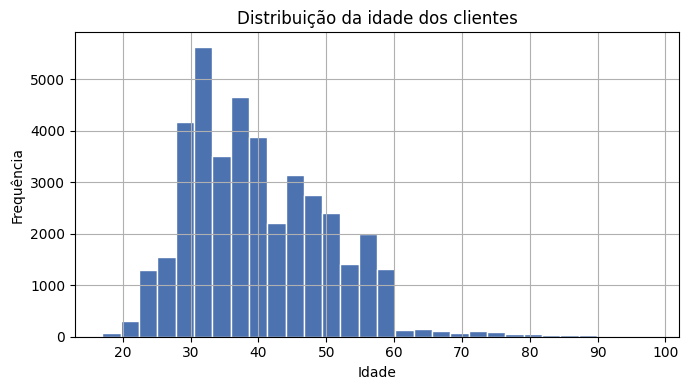

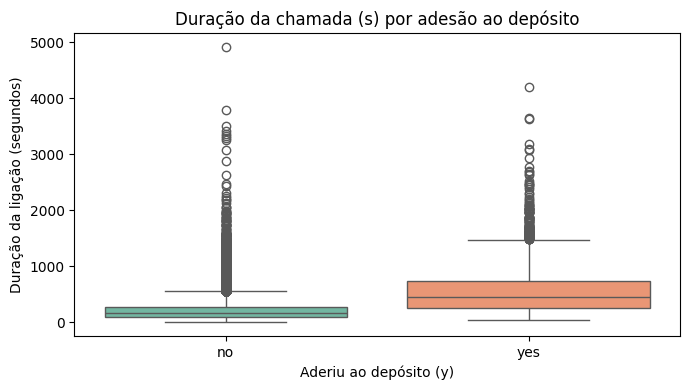

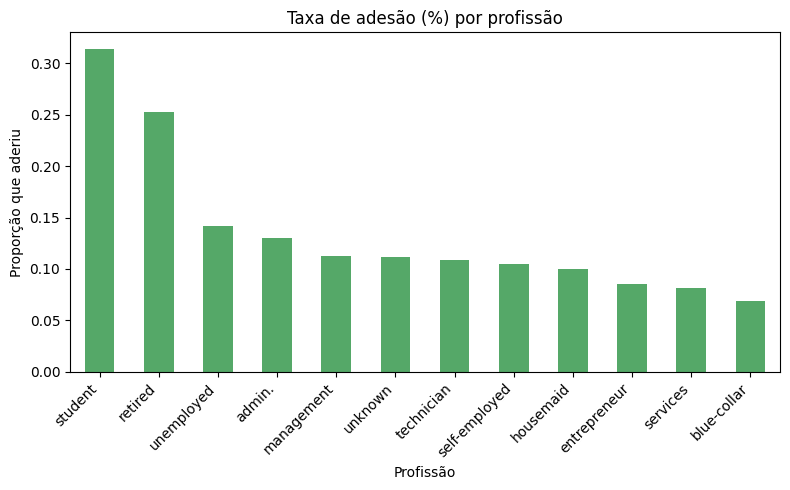

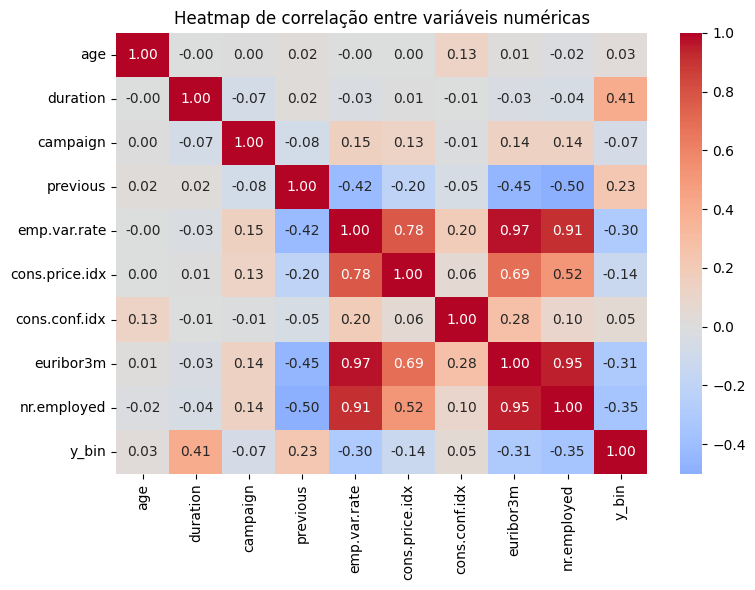

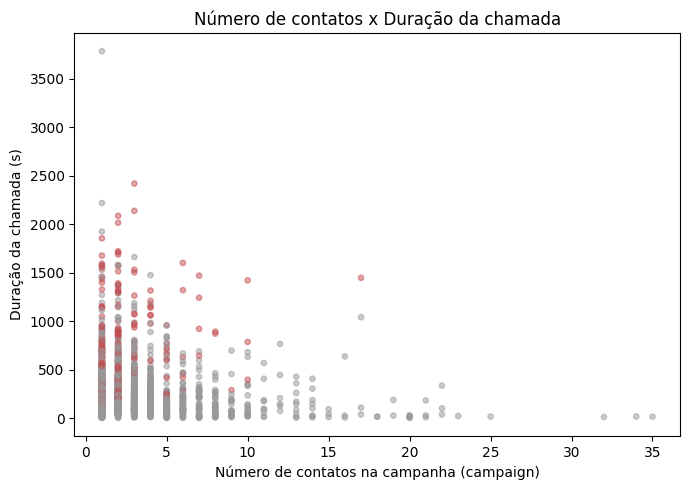

In [ ]:
# Histograma - Distribuição da idade
plt.figure(figsize=(7,4))
df['age'].hist(bins=30, color='#4C72B0', edgecolor='white')
plt.title('Distribuição da idade dos clientes')
plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

# Boxplot - Duração da chamada por adesão
plt.figure(figsize=(7,4))
sns.boxplot(x='y', y='duration', hue='y', data=df, palette='Set2', legend=False)
plt.title('Duração da chamada (s) por adesão ao depósito')
plt.xlabel('Aderiu ao depósito (y)')
plt.ylabel('Duração da ligação (segundos)')
plt.tight_layout()
plt.show()

# Gráfico de barras - Taxa de adesão por profissão
plt.figure(figsize=(8,5))
ordem = df.groupby('job')['y_bin'].mean().sort_values(ascending=False)
ordem.plot(kind='bar', color='#55A868')
plt.title('Taxa de adesão (%) por profissão')
plt.xlabel('Profissão')
plt.ylabel('Proporção que aderiu')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Heatmap de correlação
plt.figure(figsize=(8,6))
heat_cols = num_cols + ['y_bin']
sns.heatmap(df[heat_cols].corr(numeric_only=True), annot=True, fmt='.2f',
            cmap='coolwarm', center=0)
plt.title('Heatmap de correlação entre variáveis numéricas')
plt.tight_layout()
plt.show()

# Scatter plot - Nº de contatos x Duração da chamada
plt.figure(figsize=(7,5))
sample = df.sample(3000, random_state=42)
colors = sample['y'].map({'no': '#999999', 'yes': '#C44E52'})
plt.scatter(sample['campaign'], sample['duration'], c=colors, alpha=0.5, s=15)
plt.title('Número de contatos x Duração da chamada')
plt.xlabel('Número de contatos na campanha (campaign)')
plt.ylabel('Duração da chamada (s)')
plt.tight_layout()
plt.show()

### 11. TRANSFORMAÇÃO DE VARIÁVEIS

Assimetria duration original: 3.26
Assimetria duration_log     : -0.42


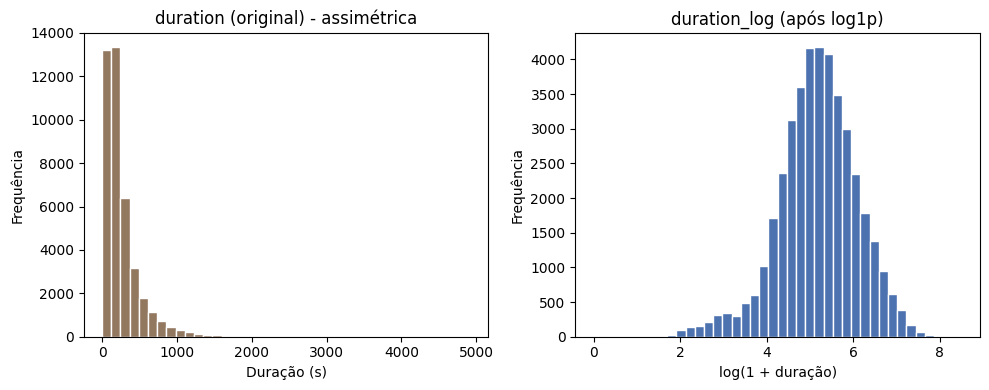


Contagem por faixa etária:


,count
faixa_etaria,
26-35,14844
36-45,12839
46-60,10919
Até 25,1665
Acima de 60,909



Taxa de adesão por faixa etária:


,y_bin
faixa_etaria,
Até 25,0.210
26-35,0.117
36-45,0.085
46-60,0.096
Acima de 60,0.455



campaign_norm describe:


,campaign_norm
count,41176.000
mean,0.029
std,0.050
min,0.000
25%,0.000
50%,0.018
75%,0.036
max,1.000


In [ ]:
# Transformação logarítmica em duration (reduz assimetria)
df['duration_log'] = np.log1p(df['duration'])
print("Assimetria duration original:", round(df['duration'].skew(), 2))
print("Assimetria duration_log     :", round(df['duration_log'].skew(), 2))

fig, axes = plt.subplots(1, 2, figsize=(10,4))
axes[0].hist(df['duration'], bins=40, color='#937860', edgecolor='white')
axes[0].set_title('duration (original) - assimétrica')
axes[0].set_xlabel('Duração (s)')
axes[0].set_ylabel('Frequência')

axes[1].hist(df['duration_log'], bins=40, color='#4C72B0', edgecolor='white')
axes[1].set_title('duration_log (após log1p)')
axes[1].set_xlabel('log(1 + duração)')
axes[1].set_ylabel('Frequência')
plt.tight_layout()
plt.show()

# Discretização da idade em faixas etárias
df['faixa_etaria'] = pd.cut(
    df['age'],
    bins=[0, 25, 35, 45, 60, 100],
    labels=['Até 25', '26-35', '36-45', '46-60', 'Acima de 60']
)

print("\nContagem por faixa etária:")
display(df['faixa_etaria'].value_counts())

print("\nTaxa de adesão por faixa etária:")
display(df.groupby('faixa_etaria', observed=False)['y_bin'].mean().round(3))

# Normalização (MinMax) de campaign
scaler = MinMaxScaler()
df[['campaign_norm']] = scaler.fit_transform(df[['campaign']])

print("\ncampaign_norm describe:")
display(df['campaign_norm'].describe().round(3))

In [ ]:
# Salvando a base com as novas colunas
df.to_csv('bank_transformado.csv', index=False)
print("\nArquivo salvo:", df.shape[0], "linhas x", df.shape[1], "colunas")


Arquivo salvo: 41176 linhas x 27 colunas


### 12. MODELAGEM

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve
from sklearn.metrics import roc_curve, auc

In [ ]:
# CENÁRIO B: MODELO REALISTA (SEM DURATION)

# Removendo preditores inadequados E a variável 'duration' (vazamento)
# O banco precisa prever ANTES da ligação, então não sabemos a duração.
colunas_remover = ['y', 'y_bin', 'duration', 'duration_log', 'emp.var.rate', 'nr.employed']
colunas_alvo = [col for col in colunas_remover if col in df.columns]
X = df.drop(columns=colunas_alvo)

# Definição do vetor alvo
y = df['y_bin']

# Tratamento da escala de 'pdays'
if 'pdays' in X.columns:
    X['pdays_nunca_contatado'] = np.where(X['pdays'].isna(), 1, 0)
    X = X.drop(columns=['pdays'])

# Transformação de variáveis categóricas (One-Hot Encoding)
X = pd.get_dummies(X, drop_first=True)

print(f"Dimensões dos preditores (REALISTA): {X.shape[0]} linhas e {X.shape[1]} colunas.")
print(f"Verificação: A coluna 'duration' está presente? {'duration' in X.columns}")

Dimensões dos preditores (REALISTA): 41176 linhas e 57 colunas.
Verificação: A coluna 'duration' está presente? False


In [ ]:
# Divisão de 70% para treino e 30% para teste (Cenário Realista)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print(f"Amostras de Treino: {X_train.shape[0]}")
print(f"Amostras de Teste: {X_test.shape[0]}")

Amostras de Treino: 28823
Amostras de Teste: 12353


In [ ]:
scaler = StandardScaler()

num_cols_real = ['age', 'campaign', 'previous', 'cons.price.idx', 'cons.conf.idx', 'euribor3m']
num_cols_presentes = [col for col in num_cols_real if col in X_train.columns]

X_train[num_cols_presentes] = scaler.fit_transform(X_train[num_cols_presentes])
X_test[num_cols_presentes] = scaler.transform(X_test[num_cols_presentes])

print("Variáveis padronizadas no cenário realista.")

Variáveis padronizadas no cenário realista.


In [ ]:
model_real = LogisticRegression(
    class_weight='balanced',
    penalty='l2',
    max_iter=1000,
    random_state=42
)

model_real.fit(X_train, y_train)
print("Modelo REALISTA treinado.")

Modelo REALISTA treinado.


In [ ]:
y_pred = model_real.predict(X_test)
y_proba = model_real.predict_proba(X_test)[:, 1]
auc_score_real = roc_auc_score(y_test, y_proba)

print("--- RELATÓRIO DE CLASSIFICAÇÃO (MODELO REALISTA) ---")
print(classification_report(y_test, y_pred, target_names=['Não Aderiu (0)', 'Aderiu (1)']))
print(f"AUC-ROC Realista: {auc_score_real:.4f}")

--- RELATÓRIO DE CLASSIFICAÇÃO (MODELO REALISTA) ---
                precision    recall  f1-score   support

Não Aderiu (0)       0.95      0.84      0.89     10961
    Aderiu (1)       0.35      0.65      0.45      1392

      accuracy                           0.82     12353
     macro avg       0.65      0.75      0.67     12353
  weighted avg       0.88      0.82      0.84     12353

AUC-ROC Realista: 0.8019


In [ ]:
# --- CENÁRIO A: MODELO VICIADO (COM DURATION) ---

# Criando cópia isolada para o cenário viciado
df_vaz = df.copy()

colunas_remover_vaz = ['y', 'y_bin', 'emp.var.rate', 'nr.employed']
X_vaz = df_vaz.drop(columns=colunas_remover_vaz)
y_vaz = df_vaz['y_bin']

# Mesmo pré-processamento, mas mantendo duration
if 'pdays' in X_vaz.columns:
    X_vaz['pdays_nunca_contatado'] = np.where(X_vaz['pdays'].isna(), 1, 0)
    X_vaz = X_vaz.drop(columns=['pdays'])

X_vaz = pd.get_dummies(X_vaz, drop_first=True)

X_train_vaz, X_test_vaz, y_train_vaz, y_test_vaz = train_test_split(
    X_vaz, y_vaz, test_size=0.3, random_state=42, stratify=y_vaz
)

# Padronização incluindo duration
scaler_vaz = StandardScaler()
num_vaz = ['age', 'duration', 'campaign', 'previous', 'cons.price.idx', 'cons.conf.idx', 'euribor3m']
X_train_vaz[num_vaz] = scaler_vaz.fit_transform(X_train_vaz[num_vaz])
X_test_vaz[num_vaz] = scaler_vaz.transform(X_test_vaz[num_vaz])

model_vaz = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model_vaz.fit(X_train_vaz, y_train_vaz)
y_proba_vaz = model_vaz.predict_proba(X_test_vaz)[:, 1]
auc_score_vaz = roc_auc_score(y_test_vaz, y_proba_vaz)

print(f"Modelo Viciado treinado. AUC-ROC: {auc_score_vaz:.4f}")

Modelo Viciado treinado. AUC-ROC: 0.9374


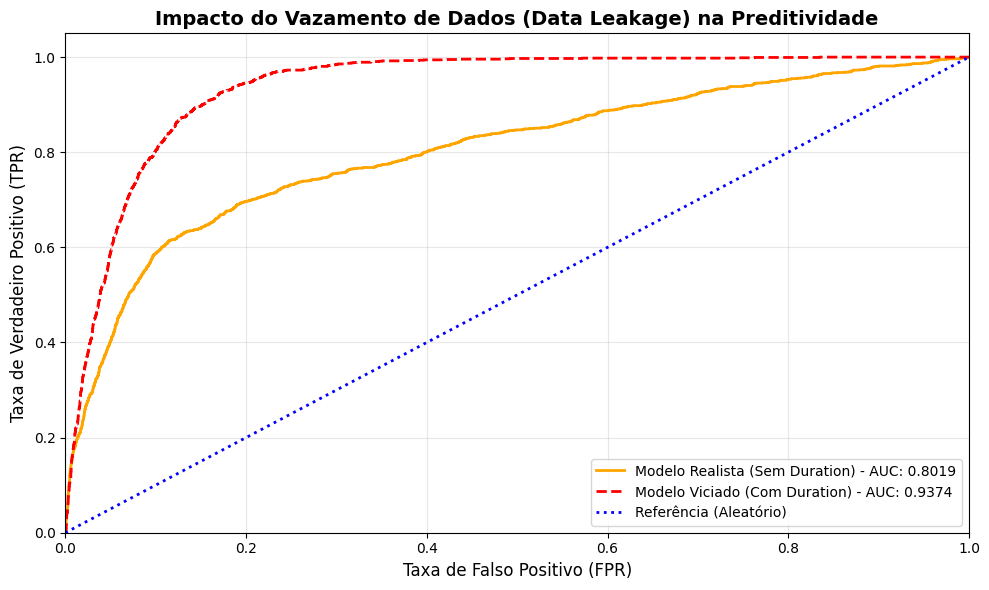

In [ ]:
# 1. Cálculo das Curvas ROC
fpr_real, tpr_real, _ = roc_curve(y_test, y_proba)
roc_auc_real = auc(fpr_real, tpr_real)

fpr_vaz, tpr_vaz, _ = roc_curve(y_test_vaz, y_proba_vaz)
roc_auc_vaz = auc(fpr_vaz, tpr_vaz)

# 2. Configuração do Gráfico Comparativo
plt.figure(figsize=(10, 6))

# Curva do Modelo Realista
plt.plot(fpr_real, tpr_real, color='orange', lw=2,
         label=f'Modelo Realista (Sem Duration) - AUC: {roc_auc_real:.4f}')

# Curva do Modelo Viciado
plt.plot(fpr_vaz, tpr_vaz, color='red', linestyle='--', lw=2,
         label=f'Modelo Viciado (Com Duration) - AUC: {roc_auc_vaz:.4f}')

# 3. Identidade Visual e Linha de Referência
plt.plot([0, 1], [0, 1], color='blue', linestyle=':', lw=2, label='Referência (Aleatório)')

# 4. Configurações de Eixos e Títulos
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falso Positivo (FPR)', fontsize=12)
plt.ylabel('Taxa de Verdadeiro Positivo (TPR)', fontsize=12)
plt.title('Impacto do Vazamento de Dados (Data Leakage) na Preditividade', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()